# Exploratory Text Analysis

In [ ]:
import re
import string
import numpy as np
import pandas as pd
import nltk

from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split

# Expected local dataset path:
# data/final_reviews.csv

DATA_PATH = "data/final_reviews.csv"
df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
print(df.head())


📊 TEXT STATISTICS PER CLASS
            word_count  sentence_count  avg_word_length  contractions  exclamations  upper_words  avg_sent_length
label                                                                                                            
fake_ai         27.846           4.021            6.293         0.041         0.488        0.002            6.816
fake_human     146.636           9.214            4.437         1.024         0.978        0.449           16.141
genuine        150.914          10.638            4.472         1.165         0.996        0.810           15.195


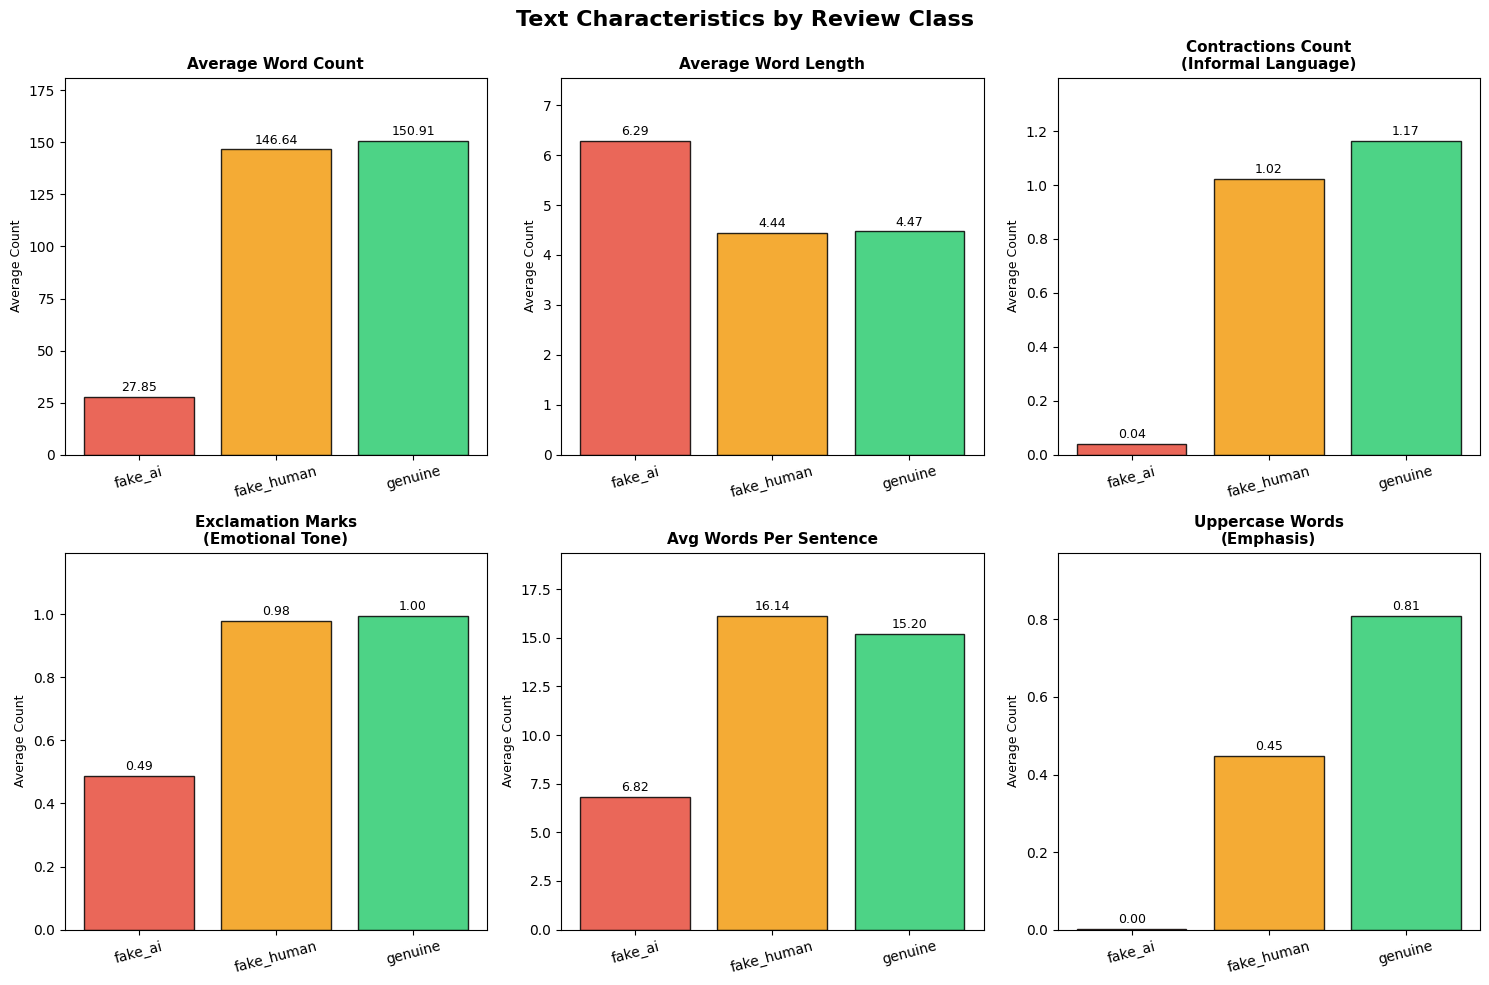


✍️  FORMALITY INDICATORS

  fake_ai:
    Avg punctuation marks : 5.63
    Reviews with NO contractions : 97.6%
    Avg character length  : 192.3

  fake_human:
    Avg punctuation marks : 14.77
    Reviews with NO contractions : 66.8%
    Avg character length  : 791.8

  genuine:
    Avg punctuation marks : 17.89
    Reviews with NO contractions : 62.0%
    Avg character length  : 821.0

🔤 TOP 10 DISTINCTIVE BIGRAMS PER CLASS

  📌 fake_ai:
      'prime location' → 0.0263
      'staff professionalism' → 0.0109
      'overall experience' → 0.0106
      'service efficiency' → 0.009
      'felt safe' → 0.0089
      'great location' → 0.0076
      'professional team' → 0.0068
      'professional staff' → 0.0067
      'unbeatable prime' → 0.0065
      'felt secure' → 0.0064

  📌 fake_human:
      'front desk' → 0.0241
      'room service' → 0.0205
      'hotel chicago' → 0.0197
      'chicago hotel' → 0.0191
      'downtown chicago' → 0.0148
      'hard rock' → 0.0144
      'recommend hotel

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import re

# ============================================================
# ANALYSIS 1: Basic Text Statistics Per Class
# ============================================================
print("=" * 60)
print("📊 TEXT STATISTICS PER CLASS")
print("=" * 60)

def get_text_stats(text):
    words = text.split()
    sentences = re.split(r'[.!?]+', text)
    sentences = [s.strip() for s in sentences if s.strip()]
    
    avg_word_length = np.mean([len(w) for w in words]) if words else 0
    
    # Count contractions (sign of informal/human writing)
    contractions = len(re.findall(
        r"\b(don't|didn't|won't|can't|isn't|wasn't|weren't|"
        r"wouldn't|shouldn't|couldn't|i'm|i've|i'd|i'll|"
        r"it's|they're|we're|you're|that's|there's)\b", 
        text.lower()
    ))
    
    # Count exclamation marks (emotional writing)
    exclamations = text.count('!')
    
    # Count uppercase words (emphasis)
    upper_words = sum(1 for w in words if w.isupper() and len(w) > 1)
    
    return {
        'word_count'      : len(words),
        'sentence_count'  : len(sentences),
        'avg_word_length' : round(avg_word_length, 2),
        'contractions'    : contractions,
        'exclamations'    : exclamations,
        'upper_words'     : upper_words,
        'avg_sent_length' : round(len(words) / max(len(sentences), 1), 2)
    }

# Apply to full dataset
stats_df = df['text'].apply(get_text_stats).apply(pd.Series)
stats_df['label'] = df['label']

# Group by label
grouped = stats_df.groupby('label').mean().round(3)
print(grouped.to_string())

# ============================================================
# ANALYSIS 2: Visualize Key Differences
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Text Characteristics by Review Class', 
             fontsize=16, fontweight='bold')

labels_order = ['fake_ai', 'fake_human', 'genuine']
colors = ['#e74c3c', '#f39c12', '#2ecc71']

metrics = [
    ('word_count',       'Average Word Count'),
    ('avg_word_length',  'Average Word Length'),
    ('contractions',     'Contractions Count\n(Informal Language)'),
    ('exclamations',     'Exclamation Marks\n(Emotional Tone)'),
    ('avg_sent_length',  'Avg Words Per Sentence'),
    ('upper_words',      'Uppercase Words\n(Emphasis)')
]

for ax, (metric, title) in zip(axes.flatten(), metrics):
    values = [grouped.loc[lbl, metric] for lbl in labels_order]
    bars = ax.bar(labels_order, values, color=colors, alpha=0.85, edgecolor='black')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylabel('Average Count', fontsize=9)
    ax.bar_label(bars, fmt='%.2f', padding=2, fontsize=9)
    ax.set_ylim(0, max(values) * 1.2)
    ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('class_text_statistics.png', dpi=150)
plt.show()



# ============================================================
# ANALYSIS 3: Punctuation & Formality Analysis
# ============================================================
print("\n" + "=" * 60)
print("✍️  FORMALITY INDICATORS")
print("=" * 60)

for label in labels_order:
    texts = df[df['label'] == label]['text']
    
    # Average punctuation per review
    avg_punct = texts.apply(
        lambda x: sum(1 for c in x if c in '.,;:!?')
    ).mean()
    
    # Reviews with NO contractions (formal writing)
    no_contraction = texts.apply(
        lambda x: len(re.findall(
            r"\b(don't|didn't|won't|can't|isn't|i'm|it's|they're)\b",
            x.lower()
        )) == 0
    ).mean() * 100
    
    # Average review length
    avg_len = texts.apply(len).mean()
    
    print(f"\n  {label}:")
    print(f"    Avg punctuation marks : {avg_punct:.2f}")
    print(f"    Reviews with NO contractions : {no_contraction:.1f}%")
    print(f"    Avg character length  : {avg_len:.1f}")

# ============================================================
# ANALYSIS 4: Top Distinctive Bigrams Per Class
# ============================================================
print("\n" + "=" * 60)
print("🔤 TOP 10 DISTINCTIVE BIGRAMS PER CLASS")
print("=" * 60)

from sklearn.feature_extraction.text import TfidfVectorizer

for label in labels_order:
    texts = df[df['label'] == label]['cleaned_text']
    
    vec = TfidfVectorizer(ngram_range=(2, 2), max_features=2000)
    tfidf_matrix = vec.fit_transform(texts)
    
    mean_tfidf = np.asarray(tfidf_matrix.mean(axis=0)).flatten()
    top_indices = mean_tfidf.argsort()[::-1][:10]
    top_bigrams = [(vec.get_feature_names_out()[i], 
                    round(mean_tfidf[i], 4)) for i in top_indices]
    
    print(f"\n  📌 {label}:")
    for bigram, score in top_bigrams:
        print(f"      '{bigram}' → {score}")